# Hamilton Recession Index — Honest Benchmarking

**Central question:** Do macroeconomic features add predictive information about the Hamilton
GDP-based recession index **beyond what a simple persistence model (AR(2)) already captures?**

**Four models, compared head-to-head on an 80 / 20 time-series split:**

| # | Model | Form |
|---|-------|------|
| **M1** | Naive persistence (oracle) | `ŷ[t] = y_actual[t-2]` — uses the *true* value from 2 months ago. Unfair upper bound. |
| **M2** | AR(2) recursive | `ŷ[t] = α + φ₁·ŷ[t-1] + φ₂·ŷ[t-2]` — **uses its own prior predictions**. Honest persistence baseline. |
| **M3** | Macro-only logit-OLS | `logit(y/100) = α + γ'·X[t-k]` — no lagged target, macro features only. |
| **M4** | **Augmented AR(2) + macro** *(main test)* | `logit(y/100) = α + φ₁·logit(y[t-1]/100) + φ₂·logit(y[t-2]/100) + γ'·X[t-k]`. Joint F-test for γ=0. |

All bounded predictions use the **logit transform** so they stay strictly in (0, 100).
Out-of-sample forecasts for models with a lagged-target term (M2, M4) are **recursive**: the
model feeds its own prior predictions back as inputs — no peeking at the true Hamilton values.

## Setup — imports, bounded-target helpers, data load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import logit as _logit, expit as _expit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11,
})

# ─── Bounded-target helpers for Hamilton Index ∈ [0, 100] ────────────────────
HAMILTON_LO, HAMILTON_HI = 0.0, 100.0

def sv_shrink(y, lo=HAMILTON_LO, hi=HAMILTON_HI, n=None):
    """Smithson–Verkuilen: push exact 0/1 off the boundary so logit is finite."""
    p = (np.asarray(y, dtype=float) - lo) / (hi - lo)
    if n is None: n = len(np.atleast_1d(p))
    return (p * (n - 1) + 0.5) / n

def to_logit(y, lo=HAMILTON_LO, hi=HAMILTON_HI, n=None):
    return _logit(sv_shrink(y, lo, hi, n))

def from_logit(z, lo=HAMILTON_LO, hi=HAMILTON_HI):
    return lo + (hi - lo) * _expit(z)

def bounded_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred)
    return {
        'R2'   : r2_score(y_true, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'OOB%' : 100.0 * np.mean((y_pred < HAMILTON_LO) | (y_pred > HAMILTON_HI)),
    }

print('✅ Libraries + bounded-target helpers ready')


✅ Libraries + bounded-target helpers ready


In [2]:
# ── Load and clean data ──────────────────────────────────────────────────────
master = pd.read_csv('/Users/pranavmoses/Desktop/ADTA5640/Project/macro_data_interpolated.csv', index_col=0, parse_dates=True)
master.columns = [c.strip().replace(' ', '_') for c in master.columns]

macro_features = ['gdp_growth', 'inflation', 'fed_funds', 'yield_spread',
                  'unemployment', 'pce_growth']

# Data is already interpolated — do NOT ffill again (would recreate the flat-block problem)

print(f'Dataset    : {master.shape}   {master.index.min().date()} → {master.index.max().date()}')
print(f'Recessions : {int((master.recession==1).sum())} months')
print(f'Hamilton   : min={master.hamilton.min():.1f}  max={master.hamilton.max():.1f}  '
      f'#zeros={int((master.hamilton==0).sum())}  #hundreds={int((master.hamilton==100).sum())}')


def shade_recessions(ax, color='#cccccc', alpha=0.4):
    rec = master['recession'].fillna(0).astype(int)
    in_rec, start, first = False, None, True
    for d, v in rec.items():
        if v == 1 and not in_rec:
            start, in_rec = d, True
        elif v == 0 and in_rec:
            ax.axvspan(start, d, color=color, alpha=alpha,
                       label='Recession' if first else None)
            in_rec, first = False, False
    if in_rec:
        ax.axvspan(start, master.index[-1], color=color, alpha=alpha)

Dataset    : (432, 9)   1990-01-31 → 2025-12-31
Recessions : 36 months
Hamilton   : min=0.0  max=100.0  #zeros=1  #hundreds=1


## EDA


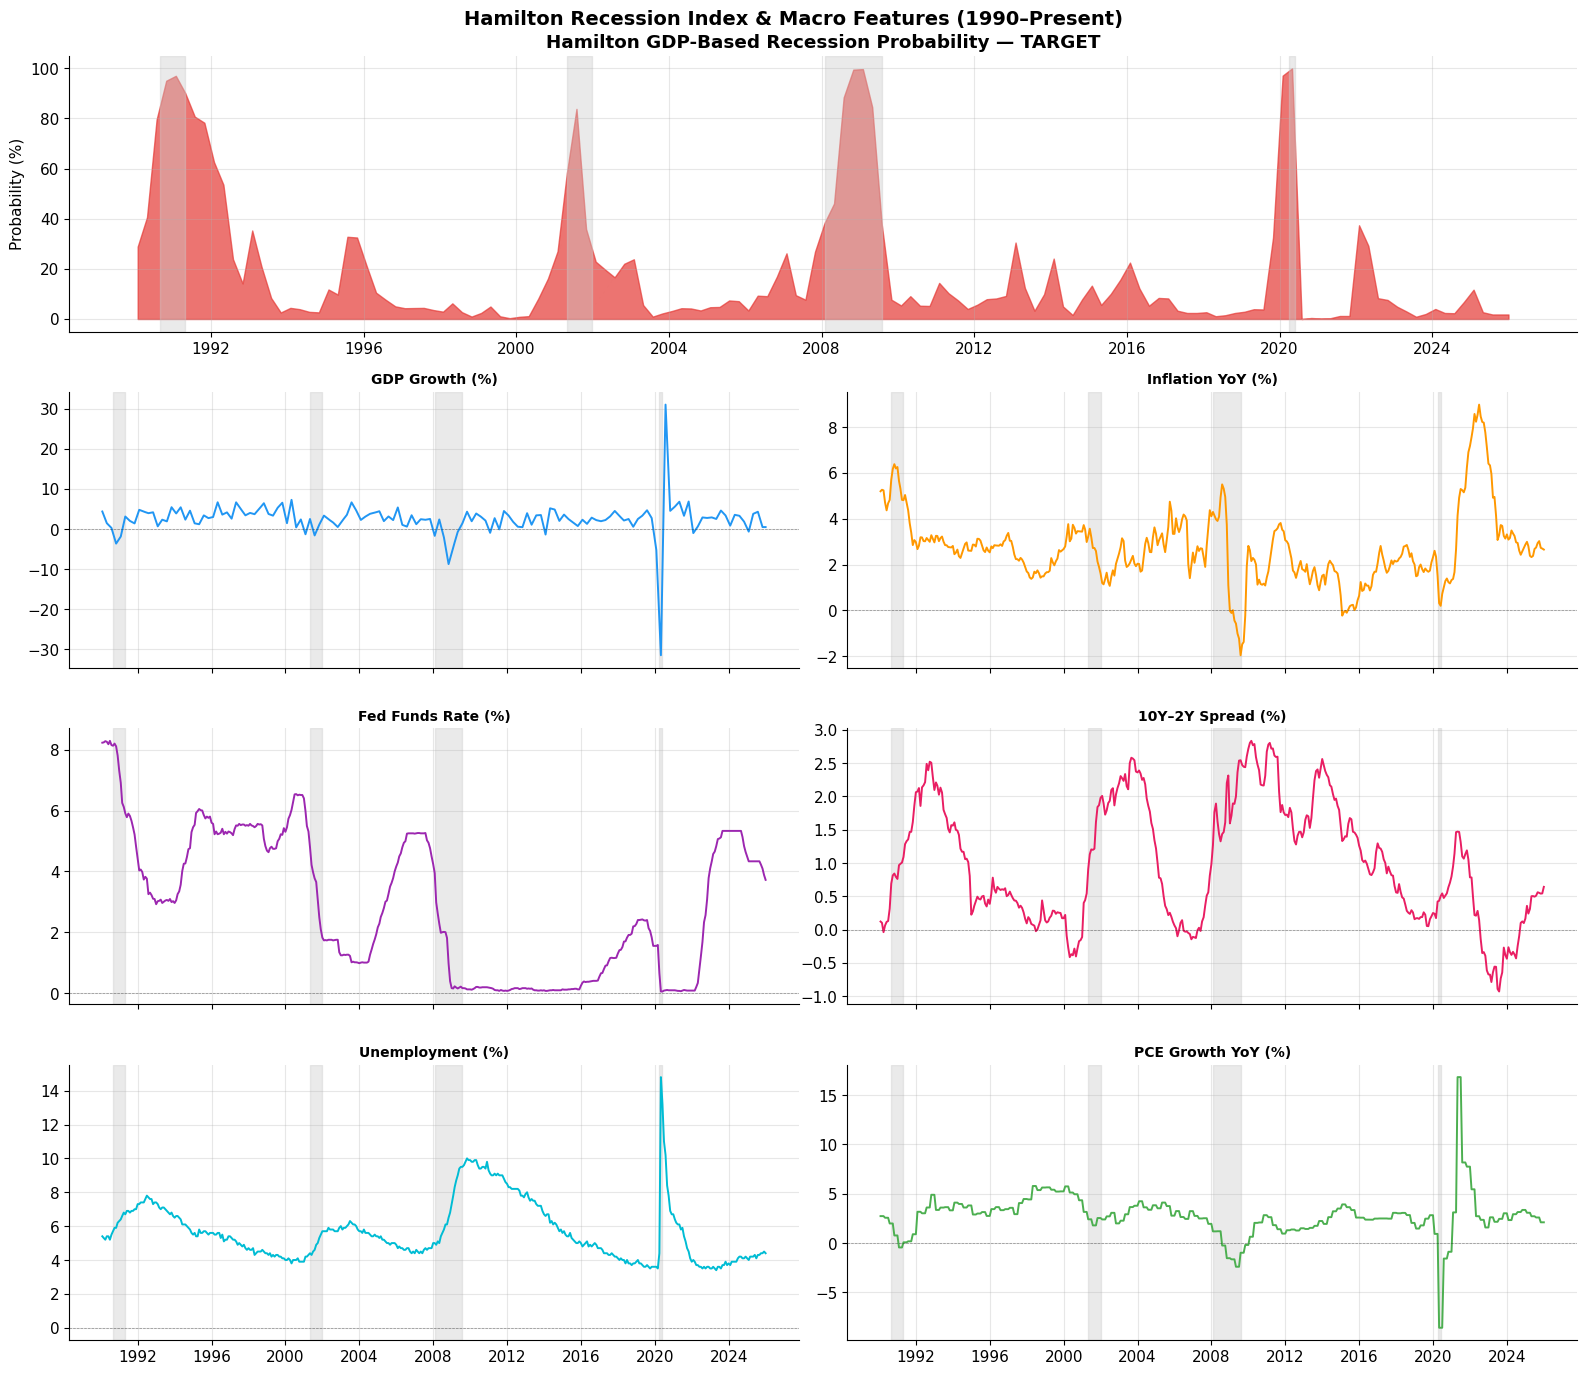

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
fig.suptitle('Hamilton Recession Index & Macro Features (1990–Present)',
             fontsize=14, fontweight='bold')

# Target on top, spans full width
axes[0, 0].remove(); axes[0, 1].remove()
ax_top = fig.add_subplot(4, 1, 1)
ax_top.fill_between(master.index, master['hamilton'], color='#E53935', alpha=0.7)
shade_recessions(ax_top)
ax_top.set_title('Hamilton GDP-Based Recession Probability — TARGET',
                 fontweight='bold')
ax_top.set_ylabel('Probability (%)')

plots = [
    ('gdp_growth',   'GDP Growth (%)',          '#2196F3'),
    ('inflation',    'Inflation YoY (%)',       '#FF9800'),
    ('fed_funds',    'Fed Funds Rate (%)',      '#9C27B0'),
    ('yield_spread', '10Y–2Y Spread (%)',       '#E91E63'),
    ('unemployment', 'Unemployment (%)',        '#00BCD4'),
    ('pce_growth',   'PCE Growth YoY (%)',      '#4CAF50'),
]
feat_axes = [axes[1, 0], axes[1, 1], axes[2, 0], axes[2, 1], axes[3, 0], axes[3, 1]]
for ax, (feat, label, color) in zip(feat_axes, plots):
    ax.plot(master.index, master[feat], color=color, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    shade_recessions(ax)
    ax.set_title(label, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 1 — Stationarity: ADF + KPSS

Every feature **and** the target are tested. Non-stationary features are replaced with first
differences.

- ADF (H₀ = non-stationary): reject (p < 0.05) ⇒ stationary.
- KPSS (H₀ = stationary): fail to reject (p > 0.05) ⇒ stationary.
- "Stationary" verdict requires both tests agree.

In [4]:
def stationarity_tests(series, name):
    s = series.dropna()
    adf_p  = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    return {
        'series': name,
        'ADF p':  round(adf_p,  4),  'ADF ok':  '✅' if adf_p  < 0.05 else '❌',
        'KPSS p': round(kpss_p, 4),  'KPSS ok': '✅' if kpss_p > 0.05 else '❌',
        'stationary': (adf_p < 0.05) and (kpss_p > 0.05),
    }

rows = [stationarity_tests(master[c], c) for c in macro_features + ['hamilton']]

stat_df = pd.DataFrame(rows)
print('─ Stationarity verdicts ─')
print(stat_df[['series','ADF p','ADF ok','KPSS p','KPSS ok','stationary']].to_string(index=False))

# Replace non-stationary FEATURES with first differences
nonstat = [r['series'] for r in rows
           if r['series'] in macro_features and not r['stationary']]

df_work = master[macro_features + ['hamilton']].copy()
for feat in nonstat:
    d = df_work[feat].diff()
    ok = stationarity_tests(d, f'd({feat})')['stationary']
    if ok:
        df_work[feat] = d
        print(f'  Replaced {feat} with first difference.')
    else:
        print(f'  ⚠️  d({feat}) still non-stationary.')
df_work = df_work.dropna()
print(f'Working df  : {df_work.shape}   {df_work.index.min().date()} → {df_work.index.max().date()}')

─ Stationarity verdicts ─
      series  ADF p ADF ok  KPSS p KPSS ok  stationary
  gdp_growth 0.0010      ✅   0.100       ✅        True
   inflation 0.0032      ✅   0.100       ✅        True
   fed_funds 0.0116      ✅   0.010       ❌       False
yield_spread 0.0088      ✅   0.100       ✅        True
unemployment 0.0725      ❌   0.100       ✅       False
  pce_growth 0.0041      ✅   0.100       ✅        True
    hamilton 0.0001      ✅   0.092       ✅        True
  Replaced fed_funds with first difference.
  Replaced unemployment with first difference.
Working df  : (431, 7)   1990-02-28 → 2025-12-31


## Step 3 — Train/test split (80 / 20)

Features are shifted by their custom lags. The target is pre-computed in three forms:

- `hamilton`          — level (0–100)
- `y_z`               — `logit(hamilton/100)`, bounded-target scale used by all models
- `y_z_lag`           — `y_z.shift(1)`, AR lag-1 term (φ₁)
- `y_z_lag2`          — `y_z.shift(2)`, AR lag-2 term (φ₂)

In [5]:
df_custom = df_work[macro_features + ['hamilton']].copy()
# for feat, lag in custom_lags.items():
#     df_custom[feat] = df_custom[feat].shift(lag)
df_custom[macro_features] = df_custom[macro_features].shift(1)
df_custom = df_custom.dropna()

# Pre-compute target transforms ONCE (using full-sample n for SV shrinkage)
n_total = len(df_custom)
df_custom['y_z']     = to_logit(df_custom['hamilton'].values, n=n_total)
df_custom['y_z_lag'] = df_custom['y_z'].shift(1)
# df_custom['y_diff']  = df_custom['hamilton'].diff()
# Instead of AR(1), use AR(2)
df_custom['y_z_lag2'] = df_custom['y_z'].shift(2)
df_custom = df_custom.dropna()
split = int(len(df_custom) * 0.80)
train, test = df_custom.iloc[:split], df_custom.iloc[split:]

y_tr = train['hamilton']; y_te = test['hamilton']

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)')
print(f'Test : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} obs)')


Train: 1990-05-31 → 2018-10-31  (342 obs)
Test : 2018-11-30  → 2025-12-31  (86 obs)


#### ACF and PACF for Recession Index

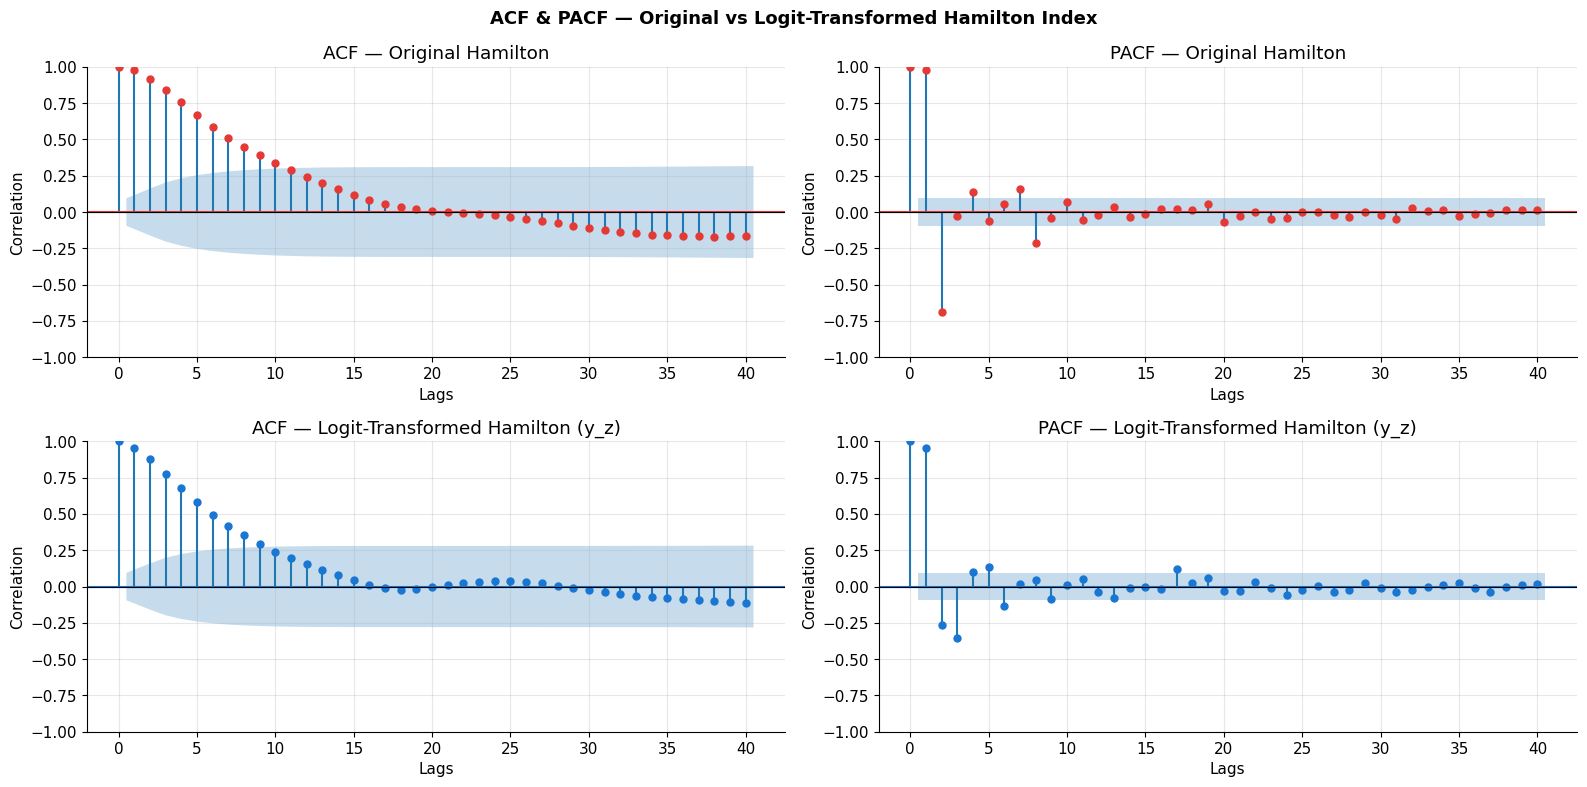

─── ACF values (first 12 lags) ───
 Lag  ACF Original  ACF Logit
   0        1.0000     1.0000
   1        0.9759     0.9517
   2        0.9194     0.8809
   3        0.8420     0.7773
   4        0.7564     0.6757
   5        0.6688     0.5827
   6        0.5854     0.4940
   7        0.5127     0.4195
   8        0.4485     0.3530
   9        0.3905     0.2922
  10        0.3371     0.2401
  11        0.2876     0.1942
  12        0.2413     0.1548


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF & PACF — Original vs Logit-Transformed Hamilton Index', 
             fontweight='bold', fontsize=13)

# ── Original Hamilton ─────────────────────────────────────────────────────────
plot_acf(df_custom['hamilton'].dropna(), lags=40, ax=axes[0, 0],
         title='ACF — Original Hamilton', color='#E53935', alpha=0.05)
plot_pacf(df_custom['hamilton'].dropna(), lags=40, ax=axes[0, 1],
          title='PACF — Original Hamilton', color='#E53935', alpha=0.05, method='ywm')

# ── Logit-Transformed Hamilton ────────────────────────────────────────────────
plot_acf(df_custom['y_z'].dropna(), lags=40, ax=axes[1, 0],
         title='ACF — Logit-Transformed Hamilton (y_z)', color='#1976D2', alpha=0.05)
plot_pacf(df_custom['y_z'].dropna(), lags=40, ax=axes[1, 1],
          title='PACF — Logit-Transformed Hamilton (y_z)', color='#1976D2', alpha=0.05, method='ywm')

for ax in axes.flat:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lags')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

# ── Numerical summary of first 12 lags ───────────────────────────────────────
from statsmodels.tsa.stattools import acf, pacf

acf_orig  = acf(df_custom['hamilton'].dropna(), nlags=12, fft=True)
acf_logit = acf(df_custom['y_z'].dropna(),      nlags=12, fft=True)

print('─── ACF values (first 12 lags) ───')
print(pd.DataFrame({
    'Lag'          : range(13),
    'ACF Original' : acf_orig.round(4),
    'ACF Logit'    : acf_logit.round(4),
}).to_string(index=False))

#### Recession index vs Logit-transformed index

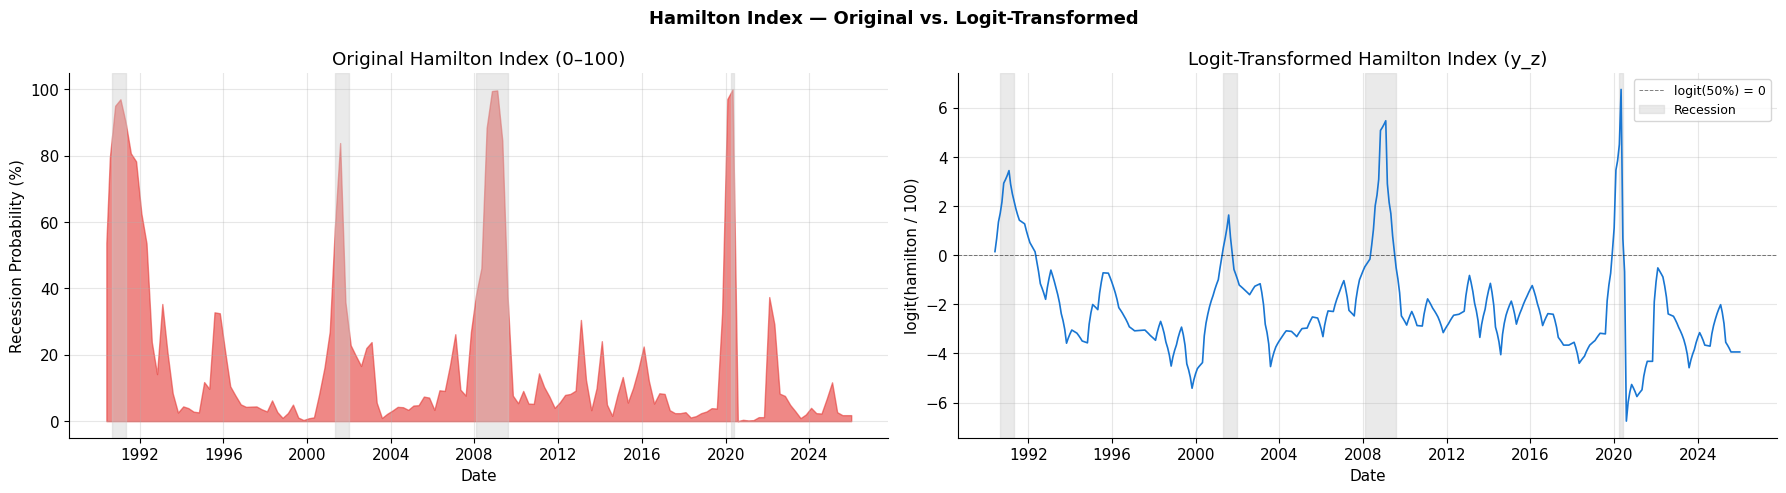

─── Distributional summary ───
       Original (0–100)  Logit-transformed
count          428.0000           428.0000
mean            18.2906            -2.1166
std             25.1670             1.9463
min              0.0000            -6.7558
25%              3.5570            -3.2690
50%              7.6777            -2.4732
75%             20.8123            -1.3322
max            100.0000             6.7558


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Hamilton Index — Original vs. Logit-Transformed', fontweight='bold', fontsize=13)

# ── Panel 1: Original (0–100) ────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df_custom.index, df_custom['hamilton'], color='#E53935', alpha=0.6)
shade_recessions(ax)
ax.set_title('Original Hamilton Index (0–100)')
ax.set_ylabel('Recession Probability (%)')
ax.set_xlabel('Date')

# ── Panel 2: Logit-transformed ───────────────────────────────────────────────
ax = axes[1]
ax.plot(df_custom.index, df_custom['y_z'], color='#1976D2', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5, label='logit(50%) = 0')
shade_recessions(ax)
ax.set_title('Logit-Transformed Hamilton Index (y_z)')
ax.set_ylabel('logit(hamilton / 100)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary stats comparison ─────────────────────────────────────────────────
print('─── Distributional summary ───')
print(pd.DataFrame({
    'Original (0–100)' : df_custom['hamilton'].describe(),
    'Logit-transformed': df_custom['y_z'].describe(),
}).round(4))

## Step 4 — Benchmarks: AR(2) persistence models

**M1 — Naive persistence (oracle).** `ŷ[t] = y_actual[t-2]`. Uses the true Hamilton value
from 2 months ago at every test step. This is an unfair upper bound — it never compounds errors.

**M2 — AR(2) recursive (honest baseline).** Fits φ₁ and φ₂ on training data, then rolls forward
using its **own prior predictions** as inputs — no access to true Hamilton values during the test period.
Errors compound over the 84-month horizon, which is why recursive R² collapses far below the oracle.

In [8]:
# ── M1: naive persistence with oracle (lag 2) ─────────────────────────────────
y_prev_oracle = pd.concat([y_tr.iloc[[-2, -1]], y_te]).shift(2).dropna()
m1_te = bounded_metrics(y_te, y_prev_oracle.values)

# ── M2: AR(2) recursive in logit space (bounded in [0, 100]) ─────────────────
X_ar_tr = sm.add_constant(train[['y_z_lag', 'y_z_lag2']])
ar_model = sm.OLS(train['y_z'], X_ar_tr).fit()

# In-sample fitted values (back-transformed to 0-100)
y_hat_m2_tr = from_logit(ar_model.predict(X_ar_tr))
m2_tr = bounded_metrics(y_tr, y_hat_m2_tr)

# OOS RECURSIVE forecast: seed with last two training observations
z_prev1 = train['y_z'].iloc[-1]   # t-1
z_prev2 = train['y_z'].iloc[-2]   # t-2

z_hats = []
for _ in range(len(test)):
    z_t = (ar_model.params['const']
           + ar_model.params['y_z_lag']  * z_prev1
           + ar_model.params['y_z_lag2'] * z_prev2)
    z_hats.append(z_t)
    z_prev2 = z_prev1   # shift: t-1 becomes t-2
    z_prev1 = z_t       # recursive: own prediction becomes new t-1

y_hat_m2 = pd.Series(from_logit(np.array(z_hats)), index=test.index)
m2_te = bounded_metrics(y_te, y_hat_m2.values)

# Contrast: AR(2) ONE-STEP-AHEAD with actual y[t-1], y[t-2] each step (oracle)
z_oracle = (ar_model.params['const']
            + ar_model.params['y_z_lag']  * test['y_z_lag'].values
            + ar_model.params['y_z_lag2'] * test['y_z_lag2'].values)
# y_hat_m2_oracle = from_logit(z_oracle)
y_hat_m2_oracle = pd.Series(from_logit(z_oracle), index=test.index)
m2_oracle = bounded_metrics(y_te, y_hat_m2_oracle)

print('── Benchmarks: persistence only (no macro features) ──')
print(f'{"Model":<44} {"R²_train":>9} {"R²_test":>9} {"RMSE_test":>10}')
print('-' * 76)
print(f'{"M1 if t-2 value is the current value":<44} '
      f'{"—":>9} {m1_te["R2"]:>9.4f} {m1_te["RMSE"]:>10.3f}')
print(f'{"M2  AR(2) Taking Actual Previous Values":<44} '
      f'{m2_tr["R2"]:>9.4f} {m2_oracle["R2"]:>9.4f} {m2_oracle["RMSE"]:>10.3f}')
print(f'{"M2  AR(2) Taking Predicted Values":<44} '
      f'{m2_tr["R2"]:>9.4f} {m2_te["R2"]:>9.4f} {m2_te["RMSE"]:>10.3f}')

# print(f'\nAR(2) coefficients in logit space:')
# print(f'  const    = {ar_model.params["const"]:+.4f}')
# print(f'  y_z_lag  = {ar_model.params["y_z_lag"]:+.4f}    (φ₁)')
# print(f'  y_z_lag2 = {ar_model.params["y_z_lag2"]:+.4f}    (φ₂ — expect negative from PACF)')

# # Stationarity check for AR(2): roots of characteristic polynomial must lie outside unit circle
# phi1 = ar_model.params['y_z_lag']
# phi2 = ar_model.params['y_z_lag2']
# roots = np.roots([1, -phi1, -phi2])
# print(f'\nAR(2) characteristic roots: {roots}')
# print(f'Moduli: {np.abs(roots).round(4)}   (all > 1 ⇒ stationary AR(2))')

── Benchmarks: persistence only (no macro features) ──
Model                                         R²_train   R²_test  RMSE_test
----------------------------------------------------------------------------
M1 if t-2 value is the current value                 —    0.5956     14.930
M2  AR(2) Taking Actual Previous Values         0.9875    0.9278      6.308
M2  AR(2) Taking Predicted Values               0.9875   -0.0744     24.336


## Step 5 — M3: Macro-only logit-OLS

Features only, no lagged target. Custom leading lags from Step 2.
Bounded via logit transform.

No recursion needed: at prediction time t, the features `X[t−k]` are from k months ago — already
observed — so this is a genuine out-of-sample forecast without either oracle updates or error compounding.


In [9]:
X_tr_m = sm.add_constant(train[macro_features])
X_te_m = sm.add_constant(test [macro_features]).reindex(columns=X_tr_m.columns, fill_value=1)

macro_model = sm.OLS(train['y_z'], X_tr_m).fit()

y_hat_m3_tr = from_logit(macro_model.predict(X_tr_m))
y_hat_m3_te = from_logit(macro_model.predict(X_te_m))
m3_tr = bounded_metrics(y_tr, y_hat_m3_tr)
m3_te = bounded_metrics(y_te, y_hat_m3_te)

print('── M3: Macro-only Logit-OLS ──')
print(macro_model.summary())
print(f'\nTrain R² : {m3_tr["R2"]:>7.4f}   RMSE : {m3_tr["RMSE"]:>6.3f}   OOB% : {m3_tr["OOB%"]:>5.2f}')
print(f'Test  R² : {m3_te["R2"]:>7.4f}   RMSE : {m3_te["RMSE"]:>6.3f}   OOB% : {m3_te["OOB%"]:>5.2f}')


── M3: Macro-only Logit-OLS ──
                            OLS Regression Results                            
Dep. Variable:                    y_z   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     144.6
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           8.10e-90
Time:                        16:38:25   Log-Likelihood:                -470.28
No. Observations:                 342   AIC:                             954.6
Df Residuals:                     335   BIC:                             981.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -

## Step 6 — M4: Augmented AR(2) + macro features — MAIN TEST

**Full model:**
$$\text{logit}(y_t / 100) = \alpha + \varphi_1\,\text{logit}(y_{t-1}/100) + \varphi_2\,\text{logit}(y_{t-2}/100) + \gamma' X_{t-k} + \varepsilon_t$$

**Restricted model (= M2):**
$$\text{logit}(y_t / 100) = \alpha + \varphi_1\,\text{logit}(y_{t-1}/100) + \varphi_2\,\text{logit}(y_{t-2}/100) + \varepsilon_t$$

**Joint F-test:** H₀ : γ₁ = ⋯ = γ₆ = 0.
Rejecting H₀ means macro features add explanatory power **beyond what AR(2) persistence already captures.**

Out-of-sample: **recursive forecast** — both AR terms use the model's own prior predictions, not true values.

In [10]:
# Full model: AR(2) lags + macro features
X_full_tr = sm.add_constant(train[['y_z_lag', 'y_z_lag2'] + macro_features])
X_full_te = sm.add_constant(test [['y_z_lag', 'y_z_lag2'] + macro_features]).reindex(
    columns=X_full_tr.columns, fill_value=1)

full_model = sm.OLS(train['y_z'], X_full_tr).fit()

# ── JOINT F-TEST: do macros add info beyond AR(2)? ────────────────────────────
constraints = ', '.join([f'{f}=0' for f in macro_features])
f_result    = full_model.f_test(constraints)
f_stat      = float(f_result.fvalue)
f_pvalue    = float(f_result.pvalue)
f_df        = (int(f_result.df_num), int(f_result.df_denom))

print('── JOINT F-TEST  H₀: macros add nothing beyond AR(2) ──')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {f_pvalue:.4e}')
print(f'  df          : {f_df}')
verdict = ('REJECT H₀ — macro features add information.'
           if f_pvalue < 0.05 else
           'FAIL TO REJECT H₀ — macros add nothing beyond AR(2).')
print(f'  Verdict (α=0.05): {verdict}')

# Incremental R² in logit space (nested OLS)
print(f'\nIn-sample R² (logit space):')
print(f'  M2 restricted (AR(2) only) : {ar_model.rsquared:.4f}')
print(f'  M4 full (AR(2) + macros)   : {full_model.rsquared:.4f}')
print(f'  Incremental R²             : {full_model.rsquared - ar_model.rsquared:+.4f}')

# ── In-sample fitted values on 0-100 scale ────────────────────────────────────
y_hat_m4_tr = from_logit(full_model.predict(X_full_tr))
m4_tr = bounded_metrics(y_tr, y_hat_m4_tr)

# ── OOS RECURSIVE forecast — AR(2): both lags use own prior predictions ───────
z_prev1 = train['y_z'].iloc[-1]   # seed t-1
z_prev2 = train['y_z'].iloc[-2]   # seed t-2

z_hats = []
for _, row in test.iterrows():
    z_t = (full_model.params['const']
           + full_model.params['y_z_lag']  * z_prev1
           + full_model.params['y_z_lag2'] * z_prev2)
    for f in macro_features:
        z_t += full_model.params[f] * row[f]
    z_hats.append(z_t)
    z_prev2 = z_prev1   # shift: t-1 becomes new t-2
    z_prev1 = z_t       # recursive: own prediction becomes new t-1

y_hat_m4 = pd.Series(from_logit(np.array(z_hats)), index=test.index)
m4_te = bounded_metrics(y_te, y_hat_m4.values)

# ── ORACLE one-step-ahead (uses true y[t-1], y[t-2] — reference only) ─────────
z_oracle = full_model.predict(X_full_te)
y_hat_m4_oracle = from_logit(z_oracle)
m4_oracle = bounded_metrics(y_te, y_hat_m4_oracle)

print('\n' + '=' * 70)
print('M4 FULL OLS SUMMARY (logit space)')
print('=' * 70)
print(full_model.summary())

print(f'\n── M4 Evaluation on 0–100 scale ──')
print(f'  Train R² (in-sample, fitted)              : {m4_tr["R2"]:>7.4f}   RMSE: {m4_tr["RMSE"]:>6.3f}')
print(f'  Test  R² Taking Actual Previous Values     : {m4_oracle["R2"]:>7.4f}   RMSE: {m4_oracle["RMSE"]:>6.3f}')
print(f'  Test  R² Taking Predicted Previous Values : {m4_te["R2"]:>7.4f}   RMSE: {m4_te["RMSE"]:>6.3f}')

── JOINT F-TEST  H₀: macros add nothing beyond AR(2) ──
  F-statistic : 4.1524
  p-value     : 4.8605e-04
  df          : (6, 333)
  Verdict (α=0.05): REJECT H₀ — macro features add information.

In-sample R² (logit space):
  M2 restricted (AR(2) only) : 0.9726
  M4 full (AR(2) + macros)   : 0.9745
  Incremental R²             : +0.0019

M4 FULL OLS SUMMARY (logit space)
                            OLS Regression Results                            
Dep. Variable:                    y_z   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     1594.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          2.66e-260
Time:                        16:38:27   Log-Likelihood:                -61.086
No. Observations:                 342   AIC:                             140.2
Df Residuals:                     333   BIC:                             

## Step 7 — Summary & final verdict

All four models side-by-side on the same 80/20 split, with **honest** out-of-sample metrics.
The bottom line is the comparison of **M4 (augmented) vs. M2 (AR(2) recursive)**:
- Does the F-test reject γ = 0? (Statistical significance of macros beyond AR(2) persistence.)
- Does M4's out-of-sample recursive R² beat M2's? (Does the signal actually generalize?)

MODEL COMPARISON  (test metrics on 0–100 scale, train 1991–2018, test 2019–2025)
                                           Model  R²_train  R²_test  RMSE_test  MAE_test
   M1  Naive persistence (lag-2 oracle — unfair)       NaN   0.5956    14.9305    6.7427
M2  AR(2) oracle (true prior values — reference)    0.9875   0.9278     6.3082    2.5375
           M2  AR(2) recursive (honest baseline)    0.9875  -0.0744    24.3363   13.8103
                        M3  Macro-only logit-OLS    0.7464   0.4266    17.7792   13.4078
            M4  AR(2) + macro oracle (reference)    0.9888   0.9178     6.7298    3.1579
            M4  AR(2) + macro recursive (honest)    0.9888  -1.9393    40.2526   29.8728

Oracle rows use true Hamilton values as AR inputs — shown for reference only.
Recursive rows are the honest evaluation: own prior predictions fed back as inputs.


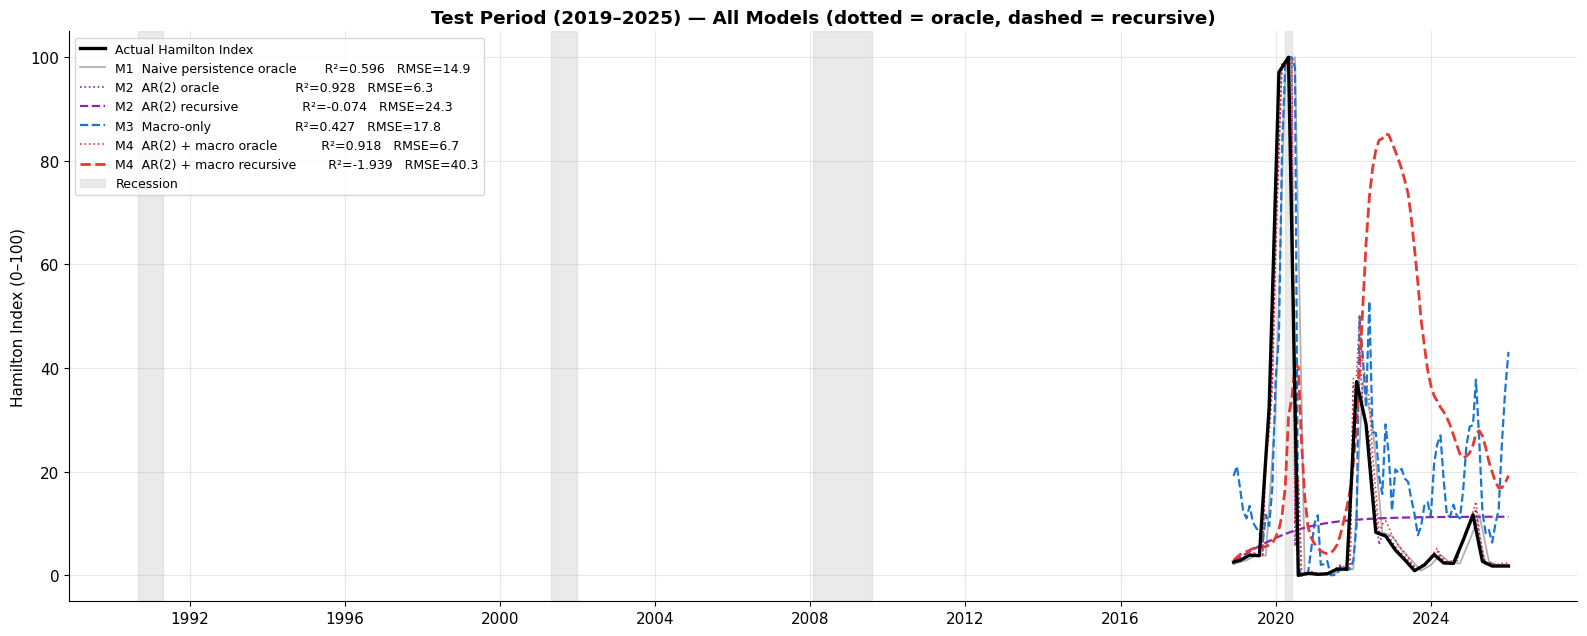


FINAL VERDICT — Do macros add information beyond AR(2) persistence?
  (1) In-sample F-test (macros | AR(2)) : F=4.152   p=4.8605e-04   df=(6, 333)
  (2) Incremental in-sample R² (logit)  : +0.0019
  (3) Out-of-sample RECURSIVE R²:
        M2 AR(2) alone      : -0.0744   RMSE=24.3
        M4 AR(2) + macros   : -1.9393   RMSE=40.3
        Δ (M4 − M2)         : -1.8649

  ⚠️   Macros are statistically significant in-sample but DO NOT improve out-of-sample R² — likely in-sample overfit.


In [11]:
# ── Comparison table ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'M1  Naive persistence (lag-2 oracle — unfair)',
     'R²_train': np.nan, 'R²_test': m1_te['R2'],
     'RMSE_test': m1_te['RMSE'], 'MAE_test': m1_te['MAE']},
    {'Model': 'M2  AR(2) oracle (true prior values — reference)',
     'R²_train': m2_tr['R2'], 'R²_test': m2_oracle['R2'],
     'RMSE_test': m2_oracle['RMSE'], 'MAE_test': m2_oracle['MAE']},
    {'Model': 'M2  AR(2) recursive (honest baseline)',
     'R²_train': m2_tr['R2'], 'R²_test': m2_te['R2'],
     'RMSE_test': m2_te['RMSE'], 'MAE_test': m2_te['MAE']},
    {'Model': 'M3  Macro-only logit-OLS',
     'R²_train': m3_tr['R2'], 'R²_test': m3_te['R2'],
     'RMSE_test': m3_te['RMSE'], 'MAE_test': m3_te['MAE']},
    {'Model': 'M4  AR(2) + macro oracle (reference)',
     'R²_train': m4_tr['R2'], 'R²_test': m4_oracle['R2'],
     'RMSE_test': m4_oracle['RMSE'], 'MAE_test': m4_oracle['MAE']},
    {'Model': 'M4  AR(2) + macro recursive (honest)',
     'R²_train': m4_tr['R2'], 'R²_test': m4_te['R2'],
     'RMSE_test': m4_te['RMSE'], 'MAE_test': m4_te['MAE']},
])

print('=' * 90)
print('MODEL COMPARISON  (test metrics on 0–100 scale, train 1991–2018, test 2019–2025)')
print('=' * 90)
print(summary.to_string(index=False, float_format=lambda v: f'{v:7.4f}'))
print()
print('Oracle rows use true Hamilton values as AR inputs — shown for reference only.')
print('Recursive rows are the honest evaluation: own prior predictions fed back as inputs.')

# ── Forecast plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6.5))
ax.plot(y_te.index, y_te.values, color='black', linewidth=2.4,
        label='Actual Hamilton Index', zorder=10)
ax.plot(y_prev_oracle.index, y_prev_oracle.values, color='#9E9E9E',
        linewidth=1.3, alpha=0.8, linestyle='-',
        label=f'M1  Naive persistence oracle       R²={m1_te["R2"]:.3f}   RMSE={m1_te["RMSE"]:.1f}')
ax.plot(y_hat_m2_oracle.index, y_hat_m2_oracle.values, color='#8E24AA',
        linewidth=1.2, linestyle=':',
        label=f'M2  AR(2) oracle                   R²={m2_oracle["R2"]:.3f}   RMSE={m2_oracle["RMSE"]:.1f}')
ax.plot(y_hat_m2.index, y_hat_m2.values, color='#8E24AA',
        linewidth=1.6, linestyle='--',
        label=f'M2  AR(2) recursive                R²={m2_te["R2"]:.3f}   RMSE={m2_te["RMSE"]:.1f}')
ax.plot(y_hat_m3_te.index, y_hat_m3_te.values, color='#1976D2',
        linewidth=1.6, linestyle='--',
        label=f'M3  Macro-only                     R²={m3_te["R2"]:.3f}   RMSE={m3_te["RMSE"]:.1f}')
ax.plot(y_hat_m4_oracle.index, y_hat_m4_oracle.values, color='#E53935',
        linewidth=1.2, linestyle=':',
        label=f'M4  AR(2) + macro oracle           R²={m4_oracle["R2"]:.3f}   RMSE={m4_oracle["RMSE"]:.1f}')
ax.plot(y_hat_m4.index, y_hat_m4.values, color='#E53935',
        linewidth=2.0, linestyle='--',
        label=f'M4  AR(2) + macro recursive        R²={m4_te["R2"]:.3f}   RMSE={m4_te["RMSE"]:.1f}')
shade_recessions(ax)
ax.set_title('Test Period (2019–2025) — All Models (dotted = oracle, dashed = recursive)',
             fontweight='bold')
ax.set_ylabel('Hamilton Index (0–100)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# ── FINAL VERDICT ────────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('FINAL VERDICT — Do macros add information beyond AR(2) persistence?')
print('=' * 80)
print(f'  (1) In-sample F-test (macros | AR(2)) : F={f_stat:.3f}   p={f_pvalue:.4e}   df={f_df}')
print(f'  (2) Incremental in-sample R² (logit)  : {full_model.rsquared - ar_model.rsquared:+.4f}')
print(f'  (3) Out-of-sample RECURSIVE R²:')
print(f'        M2 AR(2) alone      : {m2_te["R2"]:+.4f}   RMSE={m2_te["RMSE"]:.1f}')
print(f'        M4 AR(2) + macros   : {m4_te["R2"]:+.4f}   RMSE={m4_te["RMSE"]:.1f}')
print(f'        Δ (M4 − M2)         : {m4_te["R2"] - m2_te["R2"]:+.4f}')

if f_pvalue < 0.05 and m4_te['R2'] > m2_te['R2']:
    conclusion = ('✅  Macro features add BOTH statistically significant in-sample '
                  'information AND out-of-sample predictive value.')
elif f_pvalue < 0.05:
    conclusion = ('⚠️   Macros are statistically significant in-sample but DO NOT '
                  'improve out-of-sample R² — likely in-sample overfit.')
elif m4_te['R2'] > m2_te['R2']:
    conclusion = ('⚠️   Macros improve out-of-sample R² but the in-sample F-test '
                  'does not reject H₀ — signal may be small/noisy.')
else:
    conclusion = ('❌  Macros fail both tests: not significant in-sample and do '
                  'not improve out-of-sample over pure AR(2) persistence.')
print(f'\n  {conclusion}')